In [3]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

In [5]:
!wget -q "https://storage.googleapis.com/low-carbon-london/blocks/block_0.csv" -O block_0.csv

df_raw = pd.read_csv('block_0.csv', header=None,
                     names=['LCLid', 'stdorToU', 'datetime', 'energy_kwh', 'acorn', 'acorn_grouped'])

print(df_raw.shape)
print(df_raw.head())
print(df_raw.dtypes)


(0, 6)
Empty DataFrame
Columns: [LCLid, stdorToU, datetime, energy_kwh, acorn, acorn_grouped]
Index: []
LCLid            object
stdorToU         object
datetime         object
energy_kwh       object
acorn            object
acorn_grouped    object
dtype: object


In [8]:
from google.colab import files
uploaded = files.upload()   # a file picker will appear — select block_0.csv

Saving LCL-June2015v2_0.csv to LCL-June2015v2_0.csv


In [9]:
import pandas as pd

df_raw = pd.read_csv('LCL-June2015v2_0.csv',
                     header=None,
                     names=['LCLid', 'stdorToU', 'datetime', 'energy_kwh', 'acorn', 'acorn_grouped'])

# Drop the header row if it got included as data
df_raw = df_raw[df_raw['LCLid'] != 'LCLid']

print(df_raw.shape)
print(df_raw.head())
print(df_raw['LCLid'].nunique(), "unique households")

(1000000, 6)
       LCLid stdorToU  ... acorn acorn_grouped
1  MAC000002      Std  ...   NaN           NaN
2  MAC000002      Std  ...   NaN           NaN
3  MAC000002      Std  ...   NaN           NaN
4  MAC000002      Std  ...   NaN           NaN
5  MAC000002      Std  ...   NaN           NaN

[5 rows x 6 columns]
30 unique households


In [10]:
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_raw['energy_kwh'] = pd.to_numeric(df_raw['energy_kwh'], errors='coerce')
df_raw.dropna(subset=['energy_kwh'], inplace=True)

df_raw['hour']       = df_raw['datetime'].dt.hour
df_raw['dayofweek']  = df_raw['datetime'].dt.dayofweek
df_raw['month']      = df_raw['datetime'].dt.month
df_raw['is_weekend'] = (df_raw['dayofweek'] >= 5).astype(int)

print("Rows after cleaning:", df_raw.shape[0])
print("Date range:", df_raw['datetime'].min(), "→", df_raw['datetime'].max())
print(df_raw[['datetime', 'energy_kwh', 'hour', 'is_weekend']].head())


Rows after cleaning: 999971
Date range: 2011-12-06 13:00:00 → 2014-02-28 00:00:00
             datetime  energy_kwh  hour  is_weekend
1 2012-10-12 00:30:00         0.0     0           0
2 2012-10-12 01:00:00         0.0     1           0
3 2012-10-12 01:30:00         0.0     1           0
4 2012-10-12 02:00:00         0.0     2           0
5 2012-10-12 02:30:00         0.0     2           0


In [11]:
def build_features(df):
    grp = df.groupby('LCLid')

    features = pd.DataFrame({
        'mean_kwh'     : grp['energy_kwh'].mean(),
        'std_kwh'      : grp['energy_kwh'].std(),
        'max_kwh'      : grp['energy_kwh'].max(),
        'total_kwh'    : grp['energy_kwh'].sum(),

        'morning_mean' : df[df['hour'].between(6,9)].groupby('LCLid')['energy_kwh'].mean(),
        'evening_mean' : df[df['hour'].between(17,22)].groupby('LCLid')['energy_kwh'].mean(),
        'night_mean'   : df[df['hour'].between(0,5)].groupby('LCLid')['energy_kwh'].mean(),

        'weekend_mean' : df[df['is_weekend']==1].groupby('LCLid')['energy_kwh'].mean(),
        'weekday_mean' : df[df['is_weekend']==0].groupby('LCLid')['energy_kwh'].mean(),

        'peak_ratio'   : grp['energy_kwh'].max() / (grp['energy_kwh'].mean() + 1e-5),
        'zero_rate'    : (df['energy_kwh'] == 0).groupby(df['LCLid']).mean(),
    })

    features.fillna(0, inplace=True)
    return features

house_features = build_features(df_raw)
print("Households:", len(house_features))
print(house_features.round(3))

Households: 30
           mean_kwh  std_kwh  max_kwh  ...  weekday_mean  peak_ratio  zero_rate
LCLid                                  ...                                     
MAC000002     0.253    0.247    2.994  ...         0.246      11.854      0.001
MAC000003     0.398    0.615    3.921  ...         0.400       9.860      0.000
MAC000004     0.035    0.073    1.065  ...         0.035      30.091      0.767
MAC000006     0.059    0.053    0.801  ...         0.060      13.466      0.052
MAC000007     0.198    0.234    3.784  ...         0.188      19.129      0.000
MAC000008     0.363    0.242    3.581  ...         0.364       9.862      0.000
MAC000009     0.179    0.170    2.435  ...         0.178      13.610      0.000
MAC000010     0.550    0.431    4.189  ...         0.542       7.611      0.000
MAC000011     0.314    0.262    2.582  ...         0.312       8.215      0.000
MAC000012     0.044    0.080    1.345  ...         0.045      30.522      0.307
MAC000013     0.110    0.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(house_features)

# Quick check — each column should now have mean≈0 and std≈1
print("Shape:", X_scaled.shape)
print("Mean per feature (should be ~0):", X_scaled.mean(axis=0).round(2))
print("Std per feature (should be ~1):",  X_scaled.std(axis=0).round(2))

Shape: (30, 11)
Mean per feature (should be ~0): [-0. -0.  0.  0.  0. -0.  0.  0.  0. -0. -0.]
Std per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


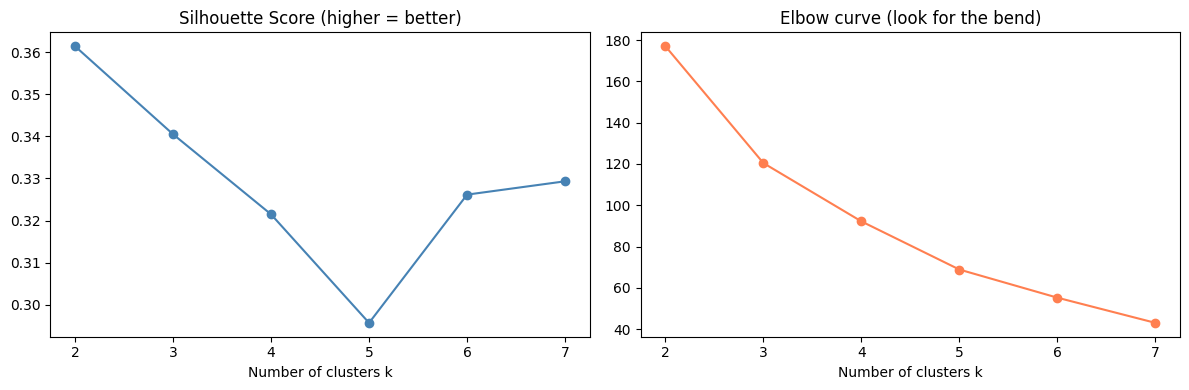

Silhouette scores: {2: np.float64(0.3614680229768338), 3: np.float64(0.34053204868007747), 4: np.float64(0.3214790539776431), 5: np.float64(0.29566067417271047), 6: np.float64(0.32616308814760336), 7: np.float64(0.3293334003195559)}
Best k: 2


In [13]:
sil_scores = {}
inertias = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)
    inertias[k] = km.inertia_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='steelblue')
ax1.set_title('Silhouette Score (higher = better)')
ax1.set_xlabel('Number of clusters k')

ax2.plot(list(inertias.keys()), list(inertias.values()), marker='o', color='coral')
ax2.set_title('Elbow curve (look for the bend)')
ax2.set_xlabel('Number of clusters k')

plt.tight_layout()
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f"Silhouette scores: {sil_scores}")
print(f"Best k: {best_k}")

In [14]:
best_k = 3  # override the automatic choice for more interesting clusters
print(f"Using k={best_k}")

Using k=3


In [15]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
house_features['cluster'] = km_final.fit_predict(X_scaled)

# See which household landed in which cluster
print("=== Households per cluster ===")
print(house_features['cluster'].value_counts().sort_index())

print("\n=== Cluster profiles (average of each feature) ===")
profile = house_features.groupby('cluster').mean().round(3)
print(profile)

print("\n=== Which household is in which cluster ===")
print(house_features[['cluster']].sort_values('cluster'))

=== Households per cluster ===
cluster
0     8
1     6
2    16
Name: count, dtype: int64

=== Cluster profiles (average of each feature) ===
         mean_kwh  std_kwh  max_kwh  ...  weekday_mean  peak_ratio  zero_rate
cluster                              ...                                     
0           0.062    0.093    1.462  ...         0.062      24.520      0.201
1           0.482    0.570    4.282  ...         0.489       8.891      0.000
2           0.224    0.215    2.459  ...         0.221      11.197      0.003

[3 rows x 11 columns]

=== Which household is in which cluster ===
           cluster
LCLid             
MAC000006        0
MAC000004        0
MAC000016        0
MAC000012        0
MAC000036        0
MAC000028        0
MAC000029        0
MAC000025        0
MAC000003        1
MAC000024        1
MAC000035        1
MAC000034        1
MAC000010        1
MAC000021        1
MAC000009        2
MAC000002        2
MAC000020        2
MAC000019        2
MAC000018        2
MA

In [16]:
from sklearn.ensemble import IsolationForest

models = {}
house_features['anomaly'] = 0
house_features['anomaly_score'] = 0.0

feature_cols = [c for c in house_features.columns
                if c not in ['cluster', 'anomaly', 'anomaly_score']]

for cluster_id in house_features['cluster'].unique():
    mask = house_features['cluster'] == cluster_id
    X_cluster = X_scaled[mask]

    iso = IsolationForest(contamination=0.15, random_state=42)
    preds = iso.fit_predict(X_cluster)
    scores = iso.decision_function(X_cluster)

    house_features.loc[mask, 'anomaly'] = (preds == -1).astype(int)
    house_features.loc[mask, 'anomaly_score'] = scores
    models[cluster_id] = iso

print(f"Total anomalies flagged: {house_features['anomaly'].sum()}")
print(f"\n=== Flagged households ===")
flagged = house_features[house_features['anomaly'] == 1][['cluster', 'mean_kwh', 'peak_ratio', 'zero_rate', 'anomaly_score']]
print(flagged.sort_values('cluster'))

Total anomalies flagged: 6

=== Flagged households ===
           cluster  mean_kwh  peak_ratio  zero_rate  anomaly_score
LCLid                                                             
MAC000028        0  0.100190   16.536858   0.015984      -0.001641
MAC000025        0  0.099312   31.715078   0.025420      -0.032090
MAC000034        1  0.566821   11.516656   0.000000      -0.054275
MAC000013        2  0.110080    4.587146   0.000000      -0.063938
MAC000008        2  0.363102    9.861974   0.000115      -0.019032
MAC000032        2  0.267544   12.483438   0.044359      -0.084441


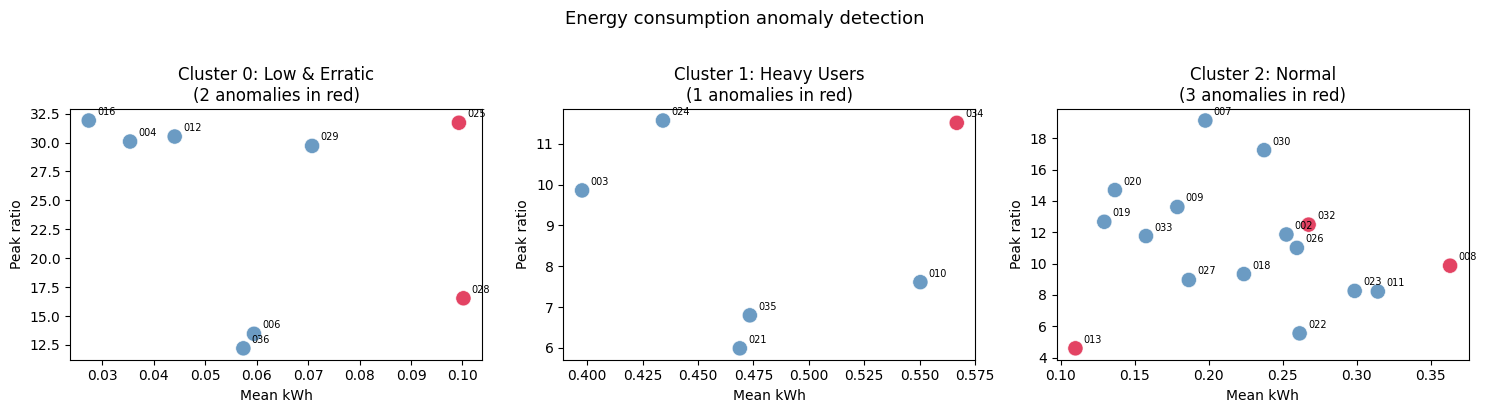

In [17]:
fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 4))
cluster_names = {0: 'Low & Erratic', 1: 'Heavy Users', 2: 'Normal'}

for i, cluster_id in enumerate(sorted(house_features['cluster'].unique())):
    sub = house_features[house_features['cluster'] == cluster_id].copy()
    ax = axes[i]

    colors = sub['anomaly'].map({0: 'steelblue', 1: 'crimson'})
    ax.scatter(sub['mean_kwh'], sub['peak_ratio'],
               c=colors, alpha=0.8, s=120, edgecolors='white', linewidth=0.5)

    # Label each dot with the MAC ID
    for idx, row in sub.iterrows():
        ax.annotate(idx[-3:],  # last 3 digits of MAC ID
                    (row['mean_kwh'], row['peak_ratio']),
                    textcoords="offset points", xytext=(6, 4), fontsize=7)

    ax.set_title(f'Cluster {cluster_id}: {cluster_names[cluster_id]}\n'
                 f'({sub["anomaly"].sum()} anomalies in red)')
    ax.set_xlabel('Mean kWh')
    ax.set_ylabel('Peak ratio')

plt.suptitle('Energy consumption anomaly detection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

dfs = []
for filename in uploaded.keys():
    temp = pd.read_csv(filename,
                       header=None,
                       names=['LCLid', 'stdorToU', 'datetime', 'energy_kwh', 'acorn', 'acorn_grouped'])
    temp = temp[temp['LCLid'] != 'LCLid']
    dfs.append(temp)
    print(f"✓ {filename} — {temp['LCLid'].nunique()} households, {len(temp):,} rows")

df_raw = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {df_raw.shape[0]:,}")
print(f"Total households: {df_raw['LCLid'].nunique()}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Saving LCL-June2015v2_0.csv to LCL-June2015v2_0 (1).csv
Saving LCL-June2015v2_106.csv to LCL-June2015v2_106.csv
Saving LCL-June2015v2_105.csv to LCL-June2015v2_105.csv
Saving LCL-June2015v2_104.csv to LCL-June2015v2_104.csv
Saving LCL-June2015v2_103.csv to LCL-June2015v2_103.csv
Saving LCL-June2015v2_102.csv to LCL-June2015v2_102.csv
Saving LCL-June2015v2_101.csv to LCL-June2015v2_101.csv
Saving LCL-June2015v2_100.csv to LCL-June2015v2_100.csv
Saving LCL-June2015v2_10.csv to LCL-June2015v2_10.csv
Saving LCL-June2015v2_1.csv to LCL-June2015v2_1.csv
✓ LCL-June2015v2_0 (1).csv — 30 households, 1,000,000 rows
✓ LCL-June2015v2_106.csv — 27 households, 1,000,000 rows
✓ LCL-June2015v2_105.csv — 28 households, 1,000,000 rows
✓ LCL-June2015v2_104.csv — 31 households, 1,000,000 rows
✓ LCL-June2015v2_103.csv — 31 households, 1,000,000 rows
✓ LCL-June2015v2_102.csv — 31 households, 1,000,000 rows
✓ LCL-June2015v2_101.csv — 32 households, 1,000,000 rows
✓ LCL-June2015v2_100.csv — 34 households, 1,0

In [19]:
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_raw['energy_kwh'] = pd.to_numeric(df_raw['energy_kwh'], errors='coerce')
df_raw.dropna(subset=['energy_kwh'], inplace=True)

df_raw['hour']       = df_raw['datetime'].dt.hour
df_raw['dayofweek']  = df_raw['datetime'].dt.dayofweek
df_raw['month']      = df_raw['datetime'].dt.month
df_raw['is_weekend'] = (df_raw['dayofweek'] >= 5).astype(int)

print("Rows after cleaning:", df_raw.shape[0])
print("Date range:", df_raw['datetime'].min(), "→", df_raw['datetime'].max())
print("Households:", df_raw['LCLid'].nunique())


Rows after cleaning: 9999708
Date range: 2011-12-06 13:00:00 → 2014-02-28 00:00:00
Households: 295


In [20]:
def build_features(df):
    grp = df.groupby('LCLid')

    features = pd.DataFrame({
        'mean_kwh'     : grp['energy_kwh'].mean(),
        'std_kwh'      : grp['energy_kwh'].std(),
        'max_kwh'      : grp['energy_kwh'].max(),
        'total_kwh'    : grp['energy_kwh'].sum(),

        'morning_mean' : df[df['hour'].between(6,9)].groupby('LCLid')['energy_kwh'].mean(),
        'evening_mean' : df[df['hour'].between(17,22)].groupby('LCLid')['energy_kwh'].mean(),
        'night_mean'   : df[df['hour'].between(0,5)].groupby('LCLid')['energy_kwh'].mean(),

        'weekend_mean' : df[df['is_weekend']==1].groupby('LCLid')['energy_kwh'].mean(),
        'weekday_mean' : df[df['is_weekend']==0].groupby('LCLid')['energy_kwh'].mean(),

        'peak_ratio'   : grp['energy_kwh'].max() / (grp['energy_kwh'].mean() + 1e-5),
        'zero_rate'    : (df['energy_kwh'] == 0).groupby(df['LCLid']).mean(),
    })

    features.fillna(0, inplace=True)
    return features

house_features = build_features(df_raw)
print("Households:", len(house_features))
print(house_features.round(3).head(10))

Households: 295
           mean_kwh  std_kwh  max_kwh  ...  weekday_mean  peak_ratio  zero_rate
LCLid                                  ...                                     
MAC000002     0.253    0.247    2.994  ...         0.246      11.854      0.001
MAC000003     0.398    0.615    3.921  ...         0.400       9.860      0.000
MAC000004     0.035    0.073    1.065  ...         0.035      30.091      0.767
MAC000006     0.059    0.053    0.801  ...         0.060      13.466      0.052
MAC000007     0.198    0.234    3.784  ...         0.188      19.129      0.000
MAC000008     0.363    0.242    3.581  ...         0.364       9.862      0.000
MAC000009     0.179    0.170    2.435  ...         0.178      13.610      0.000
MAC000010     0.550    0.431    4.189  ...         0.542       7.611      0.000
MAC000011     0.314    0.262    2.582  ...         0.312       8.215      0.000
MAC000012     0.044    0.080    1.345  ...         0.045      30.522      0.307

[10 rows x 11 columns]


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(house_features)

print("Shape:", X_scaled.shape)
print("Mean per feature (should be ~0):", X_scaled.mean(axis=0).round(2))
print("Std per feature (should be ~1):",  X_scaled.std(axis=0).round(2))

Shape: (295, 11)
Mean per feature (should be ~0): [-0. -0. -0. -0. -0. -0.  0.  0. -0.  0. -0.]
Std per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


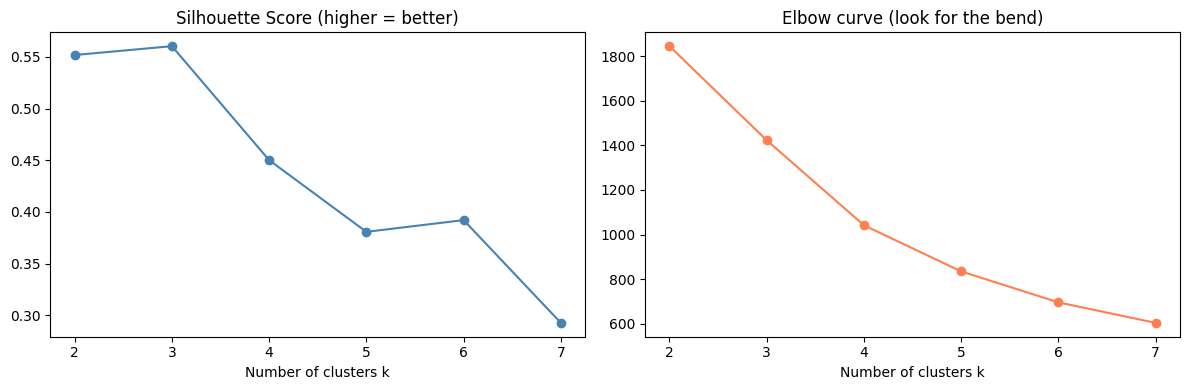

Silhouette scores: {2: np.float64(0.5518885080733678), 3: np.float64(0.5604453223320882), 4: np.float64(0.45015001929254894), 5: np.float64(0.38079184103832536), 6: np.float64(0.392139429560395), 7: np.float64(0.29269618334226255)}
Best k: 3


In [22]:
sil_scores = {}
inertias = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)
    inertias[k] = km.inertia_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='steelblue')
ax1.set_title('Silhouette Score (higher = better)')
ax1.set_xlabel('Number of clusters k')

ax2.plot(list(inertias.keys()), list(inertias.values()), marker='o', color='coral')
ax2.set_title('Elbow curve (look for the bend)')
ax2.set_xlabel('Number of clusters k')

plt.tight_layout()
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f"Silhouette scores: {sil_scores}")
print(f"Best k: {best_k}")

In [23]:
best_k = 3
print(f"Using k={best_k}")

Using k=3


In [24]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
house_features['cluster'] = km_final.fit_predict(X_scaled)

print("=== Households per cluster ===")
print(house_features['cluster'].value_counts().sort_index())

print("\n=== Cluster profiles ===")
profile = house_features.groupby('cluster').mean().round(3)
print(profile)

=== Households per cluster ===
cluster
0    233
1     61
2      1
Name: count, dtype: int64

=== Cluster profiles ===
         mean_kwh  std_kwh  max_kwh  ...  weekday_mean  peak_ratio  zero_rate
cluster                              ...                                     
0           0.158    0.161    2.039  ...         0.155      14.882      0.016
1           0.459    0.457    4.136  ...         0.455       9.949      0.002
2           0.002    0.033    0.992  ...         0.002     589.882      0.992

[3 rows x 11 columns]


In [25]:
ghost = house_features[house_features['cluster'] == 2]
print("Ghost household:")
print(ghost[['mean_kwh', 'peak_ratio', 'zero_rate', 'max_kwh']])

Ghost household:
           mean_kwh  peak_ratio  zero_rate  max_kwh
LCLid                                              
MAC000037  0.001672  589.881882   0.992499    0.992


In [26]:
# Merge the ghost household into cluster 0
house_features['cluster'] = house_features['cluster'].replace({2: 0})

print("=== Updated cluster sizes ===")
print(house_features['cluster'].value_counts().sort_index())

print("\n=== Updated profiles ===")
print(house_features.groupby('cluster').mean().round(3))

=== Updated cluster sizes ===
cluster
0    234
1     61
Name: count, dtype: int64

=== Updated profiles ===
         mean_kwh  std_kwh  max_kwh  ...  weekday_mean  peak_ratio  zero_rate
cluster                              ...                                     
0           0.157    0.161    2.035  ...         0.155      17.339      0.020
1           0.459    0.457    4.136  ...         0.455       9.949      0.002

[2 rows x 11 columns]


In [27]:
models = {}
house_features['anomaly'] = 0
house_features['anomaly_score'] = 0.0

feature_cols = [c for c in house_features.columns
                if c not in ['cluster', 'anomaly', 'anomaly_score']]

for cluster_id in house_features['cluster'].unique():
    mask = house_features['cluster'] == cluster_id
    X_cluster = X_scaled[mask]

    iso = IsolationForest(contamination=0.05, random_state=42)
    preds = iso.fit_predict(X_cluster)
    scores = iso.decision_function(X_cluster)

    house_features.loc[mask, 'anomaly'] = (preds == -1).astype(int)
    house_features.loc[mask, 'anomaly_score'] = scores
    models[cluster_id] = iso

print(f"Total anomalies flagged: {house_features['anomaly'].sum()}")
print(f"\n=== Flagged households ===")
flagged = house_features[house_features['anomaly'] == 1][['cluster', 'mean_kwh', 'peak_ratio', 'zero_rate', 'anomaly_score']]
print(flagged.sort_values(['cluster', 'anomaly_score']))

Total anomalies flagged: 15

=== Flagged households ===
           cluster  mean_kwh  peak_ratio  zero_rate  anomaly_score
LCLid                                                             
MAC000037        0  0.001672  589.881882   0.992499      -0.241218
MAC004514        0  0.258909   13.923286   0.000000      -0.079809
MAC004464        0  0.310976    9.186896   0.020597      -0.058936
MAC004313        0  0.303420    4.679822   0.000000      -0.046120
MAC004454        0  0.038249   66.416557   0.073892      -0.041222
MAC000004        0  0.035383   30.090804   0.767363      -0.040368
MAC004322        0  0.132913    8.832181   0.190739      -0.039222
MAC004478        0  0.317116    4.383116   0.000000      -0.034753
MAC000016        0  0.027351   31.907061   0.258157      -0.033066
MAC004308        0  0.035142   55.274653   0.037202      -0.015699
MAC004317        0  0.029315   40.102806   0.000000      -0.004139
MAC004369        0  0.279764   11.995405   0.000000      -0.003705
MAC000

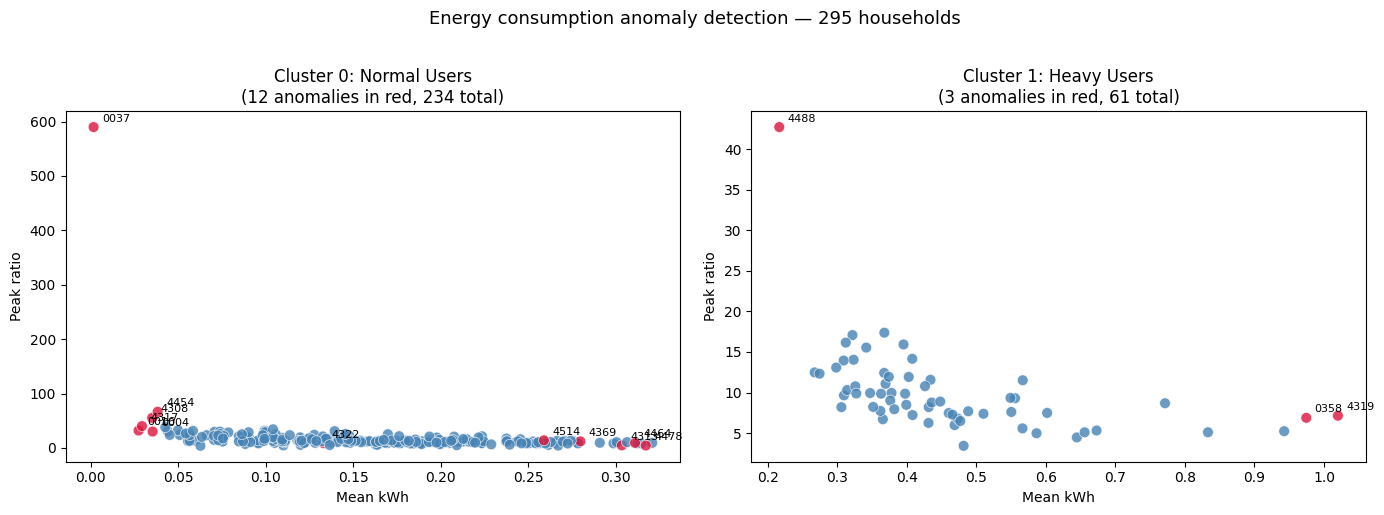

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_names = {0: 'Normal Users', 1: 'Heavy Users'}

for i, cluster_id in enumerate(sorted(house_features['cluster'].unique())):
    sub = house_features[house_features['cluster'] == cluster_id].copy()
    ax = axes[i]

    colors = sub['anomaly'].map({0: 'steelblue', 1: 'crimson'})
    ax.scatter(sub['mean_kwh'], sub['peak_ratio'],
               c=colors, alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

    # Label only the anomalies
    for idx, row in sub[sub['anomaly'] == 1].iterrows():
        ax.annotate(idx[-4:],
                    (row['mean_kwh'], row['peak_ratio']),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

    ax.set_title(f'Cluster {cluster_id}: {cluster_names[cluster_id]}\n'
                 f'({sub["anomaly"].sum()} anomalies in red, {len(sub)} total)')
    ax.set_xlabel('Mean kWh')
    ax.set_ylabel('Peak ratio')

plt.suptitle('Energy consumption anomaly detection — 295 households', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
import joblib
import json

feature_cols = [c for c in house_features.columns
                if c not in ['cluster', 'anomaly', 'anomaly_score']]

joblib.dump(scaler,    'scaler.pkl')
joblib.dump(km_final,  'kmeans.pkl')
joblib.dump(models,    'iso_forests.pkl')

with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("✓ scaler.pkl       — normalizes new input data")
print("✓ kmeans.pkl       — assigns cluster to new household")
print("✓ iso_forests.pkl  — flags anomalies within each cluster")
print("✓ feature_cols.json — feature order the model expects")

from google.colab import files
files.download('scaler.pkl')
files.download('kmeans.pkl')
files.download('iso_forests.pkl')
files.download('feature_cols.json')

✓ scaler.pkl       — normalizes new input data
✓ kmeans.pkl       — assigns cluster to new household
✓ iso_forests.pkl  — flags anomalies within each cluster
✓ feature_cols.json — feature order the model expects


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>